# Implementing Explainable AI Techniques (SHAP, LIME)

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement SHAP for model explanation
- Implement LIME for local explanations
- Explain model predictions
- Interpret feature importance
- Apply explainability to AI models

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 05 "Model Interpretability: SHAP and LIME" — the same two libraries, consolidated here into one comparison you can defend to somebody who was refused.

**Used later in:** Course 08 (AIAT 122) — Unit 4, lesson 04 "Ethical Concerns: Bias, Fairness, Interpretability".

---

This notebook covers practical activities from **Course 06, Unit 4**:
- Implementing explainable AI techniques (SHAP, LIME)

---

## Introduction

**Explainable AI (XAI)** techniques like SHAP and LIME provide insights into model decisions, enabling transparency and accountability in AI systems.


## 📌 The case: explanations that were engineered to look innocent

**Slack, Hilgard, Jia, Singh & Lakkaraju, *Fooling LIME and SHAP: Adversarial Attacks on Post
hoc Explanation Methods*, AIES 2020.**

Both LIME and SHAP work by **perturbing** an input and watching how the model responds. The
authors noticed that the perturbed points are usually **off the data distribution** — they do
not look like real records — and that a model can therefore tell when it is being explained.

So they built a *scaffold*: a wrapper that routes genuine inputs to an **extremely biased
classifier** and perturbed inputs to a harmless one. On real-world datasets **including
COMPAS**, the resulting system keeps making discriminatory predictions while LIME and SHAP
both return **innocuous explanations that do not reflect the underlying bias** — an arbitrary
explanation the adversary chooses.

Take the implication seriously before you run the cells below. An explanation supplied by a
vendor, computed on data the vendor selected, is a **marketing artefact**. It becomes evidence
only when an independent party computes it, on data the vendor did not choose, with the
ability to test the model directly.

**The WHY.** You will be asked to "add explainability" to a model, and the honest version of
that request has two halves: produce an explanation, and know what it can and cannot prove.
This notebook does both halves at once — running SHAP and LIME on the same real model and the
same real passenger, so you can see **where the two agree (a signal worth something) and where
they differ (an artefact of the method, not a fact about the person)**.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The **real Titanic passenger manifest** (`load("titanic")`) and the
  same six-feature survival model built in Notebooks 01-02, so the SHAP and LIME
  results here are directly comparable with those notebooks.
- `shap`, `lime`, `scikit-learn`.

**Outputs:** What you'll see when you run the cells

- SHAP global importance and a SHAP local explanation for one real passenger.
- A LIME explanation for that same passenger.
- A side-by-side comparison: where the two methods agree, and where they disagree.

---


In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Concept map: the two workhorse XAI methods before using them side by side below.
# Why first: SHAP and LIME answer the same question with different guarantees -
# knowing the difference tells you which to reach for.

import shap
import lime
import numpy as np

print("✅ Libraries imported!")
print("\nExplainable AI Techniques")
print("=" * 60)

# SHAP divides a prediction fairly among features (game theory) -
# consistent and additive, at a higher computational price.
print("\nSHAP (SHapley Additive exPlanations):")
print(" - Game theory-based")
print(" - Feature importance")
print(" - Global and local explanations")
print(" - Consistent explanations")

# LIME fits a tiny readable model around one prediction -
# fast and intuitive, but results vary between runs.
print("\nLIME (Local Interpretable Model-agnostic Explanations):")
print(" - Local explanations")
print(" - Model-agnostic")
print(" - Perturbation-based")
print(" - Interpretable models")

print("\nApplications:")
print(" - Model debugging")
print(" - Feature importance")
print(" - Regulatory compliance")
print(" - User trust")

print("\n✅ Explainable AI concepts understood!")

✅ Libraries imported!

Explainable AI Techniques

SHAP (SHapley Additive exPlanations):
 - Game theory-based
 - Feature importance
 - Global and local explanations
 - Consistent explanations

LIME (Local Interpretable Model-agnostic Explanations):
 - Local explanations
 - Model-agnostic
 - Perturbation-based
 - Interpretable models

Applications:
 - Model debugging
 - Feature importance
 - Regulatory compliance
 - User trust

✅ Explainable AI concepts understood!


titanic: full file, 891 rows.
Real passengers: 891 (train 668 / test 223)
Model test accuracy: 0.789



SHAP global importance (mean |SHAP|):


  is_female       0.2040
  Fare            0.0910
  Pclass          0.0865
  Age             0.0634
  SibSp           0.0292
  Parch           0.0201

Passenger #0 of the test set (a real person from the manifest):
Pclass        3.00
Age          30.00
SibSp         0.00
Parch         0.00
Fare          8.05
is_female     0.00
Model says: survival probability 0.08; this passenger actually died.

LIME explanation (local surrogate rules):
  is_female <= 0.00                   -0.3775
  2.00 < Pclass <= 3.00               -0.0637
  7.90 < Fare <= 13.86                -0.0499
  SibSp <= 0.00                       +0.0474
  Parch <= 0.00                       -0.0252
  28.00 < Age <= 36.00                -0.0176

SHAP local attributions for the SAME passenger:
  is_female       -0.1193
  Fare            -0.1071
  Age             -0.0418
  Pclass          -0.0256
  Parch           -0.0150
  SibSp           +0.0058

SHAP's strongest factor for this passenger: is_female
LIME's strongest facto

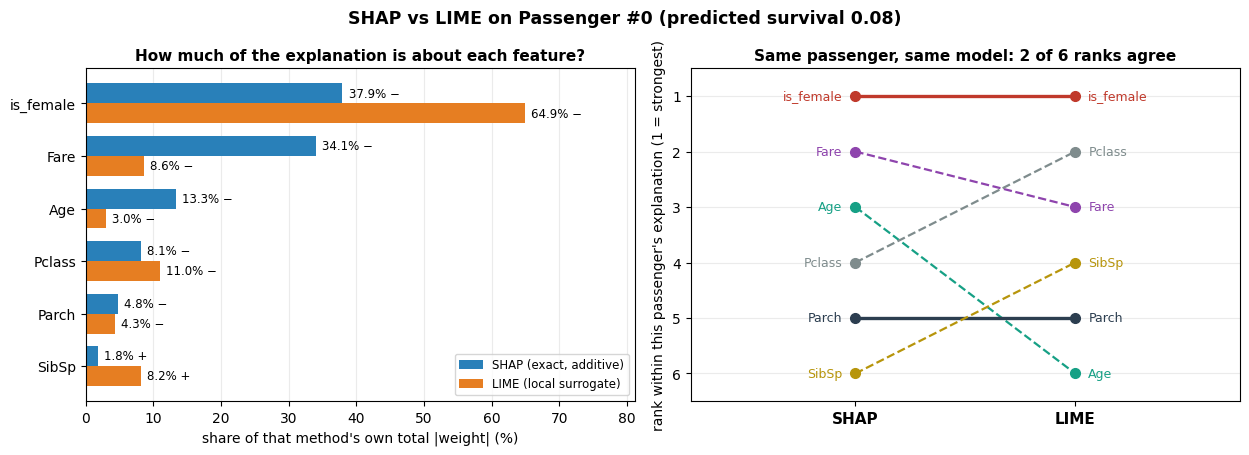


Share of each method's own explanation given to 'is_female': SHAP 37.9%, LIME 64.9%
Share given to 'Fare':  SHAP 34.1%, LIME 8.6%
Two defensible methods, one model, one passenger - and two different
stories about what the decision was mostly about.


In [3]:
# WHY side by side: running BOTH methods on the same model and the same real
# person shows where they agree (a signal you can trust) and where they differ
# (an artifact of the method, not a fact about the passenger).

# Practice: compute BOTH SHAP and LIME explanations on one model
import numpy as np
import pandas as pd
import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings('ignore')  # silence sklearn feature-name warning from LIME's numpy inputs
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Same REAL setup as Notebooks 01-02: the Titanic manifest, six interpretable
# features, one recorded outcome. Explaining a model trained on real people is
# what makes the explanation a statement about the world.
df = load("titanic")
df['Age'] = df['Age'].fillna(df['Age'].median())      # 177 ages are genuinely missing
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  # 2 ports missing

X = pd.DataFrame({
    'Pclass':    df['Pclass'].astype(float),      # ticket class: 1 = first, 3 = third
    'Age':       df['Age'].astype(float),         # years (median-imputed where missing)
    'SibSp':     df['SibSp'].astype(float),       # siblings/spouse aboard
    'Parch':     df['Parch'].astype(float),       # parents/children aboard
    'Fare':      df['Fare'].astype(float),        # ticket price paid
    'is_female': (df['Sex'] == 'female').astype(float),  # 1 = female, 0 = male
})
y = df['Survived'].values                          # 1 = survived, 0 = died

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42).fit(X_train, y_train)
print(f"Real passengers: {len(df)} (train {len(X_train)} / test {len(X_test)})")
print(f"Model test accuracy: {accuracy_score(y_test, model.predict(X_test)):.3f}")

# ---- SHAP: exact, additive attributions for the whole test set ----
sv = shap.TreeExplainer(model).shap_values(X_test)
sv1 = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if sv.ndim == 3 else sv)
shap_rank = pd.Series(np.abs(sv1).mean(axis=0), index=X_test.columns
                      ).sort_values(ascending=False)
print("\nSHAP global importance (mean |SHAP|):")
for f, v in shap_rank.items():
    print(f"  {f:<15} {v:.4f}")

# ---- LIME: a fast local surrogate around ONE real passenger ----
i = 0
proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
lime_exp = LimeTabularExplainer(
    X_train.values, feature_names=list(X_train.columns),
    class_names=['died', 'survived'], mode='classification', random_state=42,
).explain_instance(X_test.iloc[i].values, model.predict_proba, num_features=6)
print(f"\nPassenger #{i} of the test set (a real person from the manifest):")
print(X_test.iloc[i].round(2).to_string())
print(f"Model says: survival probability {proba:.2f}; "
      f"this passenger actually {'survived' if y_test[i] == 1 else 'died'}.")
print("\nLIME explanation (local surrogate rules):")
for rule, w in lime_exp.as_list():
    print(f"  {rule:<35} {w:+.4f}")

# ---- SHAP local, same passenger, for a like-for-like comparison ----
shap_local = pd.Series(sv1[i], index=X_test.columns)
print("\nSHAP local attributions for the SAME passenger:")
for f, v in shap_local.sort_values(key=abs, ascending=False).items():
    print(f"  {f:<15} {v:+.4f}")

# ---- Do the two methods agree? Compare their top local feature, computed ----
shap_top = shap_local.abs().idxmax()
lime_top = max(lime_exp.as_map()[1], key=lambda t: abs(t[1]))[0]
lime_top_name = X_test.columns[lime_top]
print("\n" + "="*70)
print(f"SHAP's strongest factor for this passenger: {shap_top}")
print(f"LIME's strongest factor for this passenger: {lime_top_name}")
print("They AGREE on the dominant factor." if shap_top == lime_top_name
      else "They DISAGREE on the dominant factor.")
print(f"Globally, SHAP ranks '{shap_rank.index[0]}' as the most influential feature")
print(f"across all {len(X_test)} test passengers ({shap_rank.iloc[0]:.4f} mean |SHAP|).")

# Agreement is not all-or-nothing: compare the FULL local ordering, not just #1.
shap_order = list(shap_local.abs().sort_values(ascending=False).index)
lime_order = [X_test.columns[j] for j, _ in
              sorted(lime_exp.as_map()[1], key=lambda t: -abs(t[1]))]
matches = sum(a == b for a, b in zip(shap_order, lime_order))
print(f"\nSHAP order: {shap_order}")
print(f"LIME order: {lime_order}")
print(f"Positions where the two orderings match: {matches} of {len(shap_order)}")
print("\nThe headline factor is the same, and the tail ordering is not. That is the")
print("practical lesson: SHAP is exact and additive for this tree model, LIME fits")
print("a fast approximate surrogate around one point, so their minor ranks drift.")
print("Report which method produced an explanation - an explanation without its")
print("method is not evidence, and a rank you cannot reproduce is not a finding.")

# --- Draw the comparison, because a table of six numbers hides the shape of it ---
# WHY normalise: LIME's weights and SHAP's attributions are NOT on the same
# scale (LIME fits a surrogate; SHAP splits the prediction), so plotting the raw
# numbers side by side would compare two different units. Expressing each as a
# SHARE of that method's own total |weight| puts them on one honest axis: "how
# much of this explanation is about this feature?"
import matplotlib.pyplot as plt

lime_local = pd.Series({X_test.columns[j]: w for j, w in lime_exp.as_map()[1]})
shap_share = (shap_local.abs() / shap_local.abs().sum() * 100)
lime_share = (lime_local.abs() / lime_local.abs().sum() * 100)
order = list(shap_share.sort_values(ascending=False).index)   # sorted by SHAP

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))

ax = axes[0]
ypos = np.arange(len(order))
h = 0.38
b_s = ax.barh(ypos - h / 2, [shap_share[f] for f in order], h,
              color='#2980b9', label='SHAP (exact, additive)')
b_l = ax.barh(ypos + h / 2, [lime_share[f] for f in order], h,
              color='#e67e22', label='LIME (local surrogate)')
# A "+" marks a feature that pushed this passenger TOWARD survival, so the
# shares can be read without losing the direction of each contribution.
for bars, series in ((b_s, shap_local), (b_l, lime_local)):
    for bar, f in zip(bars, order):
        sign = '+' if series[f] > 0 else '−'
        ax.text(bar.get_width() + 0.9, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.1f}% {sign}", va='center', fontsize=8.5)
ax.set_yticks(ypos)
ax.set_yticklabels(order, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, max(lime_share.max(), shap_share.max()) * 1.25)
ax.set_xlabel("share of that method's own total |weight| (%)")
ax.set_title('How much of the explanation is about each feature?',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5, loc='lower right')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)

# --- Right: the ordering, which is what a caseworker would actually write down
ax = axes[1]
s_rank = {f: k + 1 for k, f in enumerate(shap_order)}
l_rank = {f: k + 1 for k, f in enumerate(lime_order)}
# Deliberately avoids the blue and orange used for SHAP/LIME in the left
# panel: here the colours track FEATURES, not methods.
palette = ['#c0392b', '#8e44ad', '#16a085', '#7f8c8d', '#2c3e50', '#b7950b']
for k, f in enumerate(shap_order):
    agree = s_rank[f] == l_rank[f]
    ax.plot([0, 1], [s_rank[f], l_rank[f]], '-o', color=palette[k % 6],
            lw=2.4 if agree else 1.6, ms=7,
            ls='-' if agree else '--')
    ax.text(-0.06, s_rank[f], f, ha='right', va='center', fontsize=9,
            color=palette[k % 6])
    ax.text(1.06, l_rank[f], f, ha='left', va='center', fontsize=9,
            color=palette[k % 6])
ax.set_xticks([0, 1])
ax.set_xticklabels(['SHAP', 'LIME'], fontsize=11, fontweight='bold')
ax.set_xlim(-0.75, 1.75)
ax.set_yticks(range(1, len(shap_order) + 1))
ax.set_ylim(len(shap_order) + 0.5, 0.5)
ax.set_ylabel('rank within this passenger\'s explanation (1 = strongest)')
ax.set_title(f'Same passenger, same model: {matches} of {len(shap_order)} '
             f'ranks agree', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)

fig.suptitle(f'SHAP vs LIME on Passenger #{i} (predicted survival {proba:.2f})',
             fontsize=12.5, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nShare of each method's own explanation given to '{shap_order[0]}': "
      f"SHAP {shap_share[shap_order[0]]:.1f}%, LIME {lime_share[shap_order[0]]:.1f}%")
print(f"Share given to 'Fare':  SHAP {shap_share['Fare']:.1f}%, "
      f"LIME {lime_share['Fare']:.1f}%")
print("Two defensible methods, one model, one passenger - and two different")
print("stories about what the decision was mostly about.")

**Read the figure.**

*Left.* Six features, two bars each. Because LIME's surrogate weights and SHAP's attributions
are not in the same unit, each bar is that feature's share of **its own method's** total
weight — "how much of this explanation is about this feature". The `−` and `+` signs keep the
direction: everything pushed this passenger away from survival except `SibSp`. Now compare the
two bars for `is_female`: SHAP gives it **37.9%** of the explanation, LIME gives it **64.9%**.
And `Fare`: SHAP **34.1%**, LIME **8.6%**. SHAP's story is "sex and fare, roughly equally";
LIME's story is "overwhelmingly sex". Both are defensible outputs of published methods run
correctly on the same model and the same person.

*Right.* The same disagreement as a ranking, which is the form a caseworker would actually
write down. Solid lines are ranks the two methods agree on, dashed lines are ranks they do
not: only **2 of 6** positions match — the top feature and `Parch` at rank 5. `Fare` is SHAP's
second reason and LIME's third; `Age` is SHAP's third and LIME's last.

**What this proves.** That "we ran an explainability method" is not a finding. The headline
agrees, so a one-line summary would look robust; everything under the headline depends on
which method you ran, and neither figure tells you which one is right. **What it does not
prove:** that one method is better. They answer different questions — SHAP splits this
prediction additively, LIME fits a readable model in a neighbourhood — and the honest
deliverable names the method, the seed and the data it was run on.

## 💬 Discuss

Your run explained one real passenger — third class, age 30, fare 8.05, male, predicted
survival **0.08**, and in fact he died — with both methods:

| Feature | LIME (rule weight) | SHAP (attribution) |
|---|---|---|
| `is_female` | **−0.3775** | **−0.1193** |
| `Fare` | −0.0499 | −0.1071 |
| `Age` | −0.0176 | −0.0418 |
| `Pclass` | −0.0637 | −0.0256 |

1. **They agree on the top feature and disagree on everything else.** LIME ranks `Pclass`
   second; SHAP ranks `Fare` second and gives it nearly as much weight as sex. Which ordering
   do you report? If your answer is "the one they agree on", note that leaves you with a
   single feature and no explanation of the rest — is that an acceptable deliverable, and
   what would you say it means?
2. **What would you accept as proof from a vendor?** Given Slack et al., write the clause you
   would put in a procurement contract to make an explainability claim mean something. Be
   concrete: who computes the explanations, on which data, with what access to the model, and
   what happens if the answer is unflattering. Then say honestly whether a small supplier
   could meet your clause — and what you do if only the large ones can.
3. **Does agreement between two methods prove anything?** Both LIME and SHAP perturb inputs,
   so both are vulnerable to the *same* scaffolding attack. Two methods sharing a blind spot
   agreeing with each other is not independent corroboration. What kind of second check
   actually is independent — retraining without the feature, a randomised controlled test on
   the deployed system, or an audit of outcomes (Unit 2)? Rank them by what they cost.


## ⚠️ Where this breaks

- **Post-hoc explanation is not an audit, and can be adversarially defeated.** Slack et al.
  (2020) is the standing counter-example: extreme bias plus innocuous explanations, on COMPAS
  data. If the model owner controls the explanation pipeline, the explanation proves nothing.
- **Agreement between LIME and SHAP is weak evidence.** They share the perturbation
  assumption. When they disagree — as they do above on `Fare` versus `Pclass` — you have
  learned that at least one is an artefact of its method, not a fact about the passenger.
- **LIME is stochastic and its neighbourhood is a free parameter.** Rerun it and the weights
  move; change the kernel width and the ranking can move. Fix and report the seed, and
  remember that reproducing one draw is not the same as being right.
- **Neither method is causal.** "`is_female` contributed −0.12" describes this model's
  arithmetic. It is not a claim about what would have happened to this man, and Notebook 03
  shows exactly how badly that translation fails when you turn an attribution into advice.
- **Explaining a model that should not exist is the most expensive kind of compliance.** SHAP
  told us the strongest driver of this model is a protected attribute. That is a finding about
  whether to ship, not a box to tick.

**The cheaper alternative:** where the data is tabular and the decision is high-stakes, an
**inherently interpretable model** — a scored list, a shallow tree, a GAM — removes the whole
attack surface, because there is no post-hoc pipeline for an adversary to scaffold. Reach for
SHAP and LIME when you genuinely need a black box, and then have someone else run them.


## 🔭 State of the field (2026)

SHAP and LIME both assume a model with a fixed feature vector and one scalar output - exactly the model
you explained here, and exactly what a 2026 language model is not. Two things fill that gap in current
practice, one of them a trap. The trap is treating the model's own chain of thought as the explanation:
reasoning models mentioned a hint they demonstrably used in fewer than 20% of cases, and reinforcement
learning improved that faithfulness only up to a plateau, so a readable trace is not a faithful account
of the computation (Chen et al., 2025, arXiv:2505.05410). The technique that does inspect the
computation is sparse-feature decomposition of internal activations, which has moved from research
artefact to ordinary tooling - open sparse autoencoders released for a whole model family and used for
steering, evaluation analysis and post-training work (Deng et al., 2026, arXiv:2605.11887).

Run the pair first anyway. The comparison you did here - one model, one person, two methods, and an
honest reading of where they disagree - is the discipline every newer method still needs, and the Slack
et al. attack is the reason: "we ran an explainability method" is a claim, not a finding. SHAP and LIME
are the techniques the official plan names for this unit.

## 📚 References

1. Ribeiro, M. T., Singh, S. & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. KDD 2016. <https://arxiv.org/abs/1602.04938>
2. Lundberg, S. M. & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017. <https://arxiv.org/abs/1705.07874>
3. Barredo Arrieta, A., Díaz-Rodríguez, N., Del Ser, J., et al. (2020). *Explainable Artificial Intelligence (XAI): Concepts, Taxonomies, Opportunities and Challenges toward Responsible AI*. Information Fusion, 58. <https://arxiv.org/abs/1910.10045>
4. Slack, D., Hilgard, S., Jia, E., Singh, S. & Lakkaraju, H. (2020). *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods*. AIES 2020. <https://arxiv.org/abs/1911.02508>
5. Chen, Y., Benton, J., Radhakrishnan, A., Uesato, J., Denison, C., Schulman, J., et al. (2025). *Reasoning Models Don't Always Say What They Think*. <https://arxiv.org/abs/2505.05410>
6. Deng, B., Wang, X., Wang, Y., Wan, Y., Ma, Y., Yang, B., et al. (2026). *Qwen-Scope: Turning Sparse Features into Development Tools for Large Language Models*. <https://arxiv.org/abs/2605.11887>
